fid 28 | class: Degradation | VIEW_DATE: 2023-10-19 00:00:00 | area: 32.93kha

acquisitions per window: {'aft': 1, 'bef': 12}
polygon tokens per date: 54  <- if this is tiny, expect noise
      date win     p_sum  n_tok  n_nonforest  n_tiles   p_dist
2023-03-01 bef 36.525024     54           37        3 0.676389
2023-04-30 bef 24.123858     54           12        3 0.446738
2023-05-15 bef 26.416559     54           21        3 0.489196
2023-06-04 bef 23.372885     54            8        3 0.432831
2023-06-09 bef 30.445156     54           27        3 0.563799
2023-06-24 bef 39.042605     54           45        3 0.723011
2023-07-09 bef 31.780386     54           32        3 0.588526
2023-07-19 bef 34.380543     54           35        3 0.636677
2023-07-29 bef 36.616922     54           38        3 0.678091
2023-08-08 bef 38.905590     54           46        3 0.720474
2023-08-23 bef 40.059574     54           44        3 0.741844
2023-10-02 bef 39.496266     54           45        3 0.

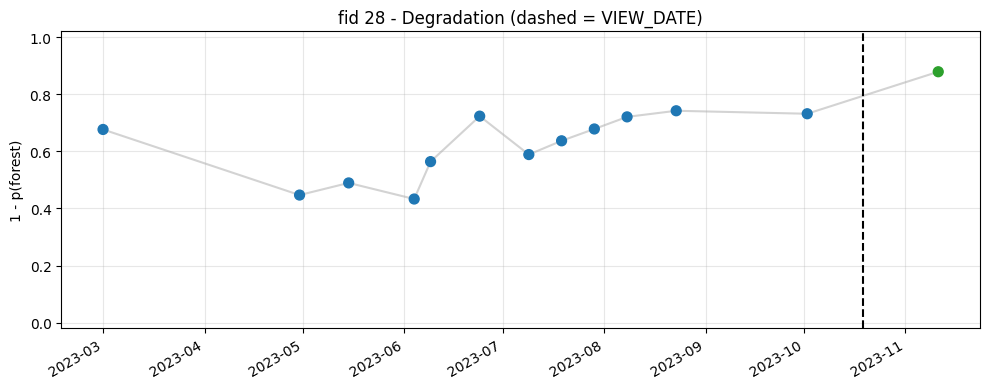

In [2]:
import glob
import re

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize

from rand_forest import majority_downsample

#FID = "83" "63"
FID = "28"
TILES = "/share/castor/home/e2406749/thesis_tiles_120px"

# Already-trained classifier: 7 classes, column 0 = forest
clf = joblib.load("results/log_reg/model.joblib")

# --- Disturbance polygon for this FID -------------------------------------
# Reprojected to the tiles' CRS so the rasterization lands on the right pixels.
gdf = gpd.read_file("data_shp/label_polygons.shp").to_crs("EPSG:3857")
gdf["fid"] = gdf["fid"].astype(int).astype(str)          # stored as float (51.0)
sub = gdf[gdf["fid"] == FID] # (geometry, value) pairs, the format rasterize expects. Value 1 = inside.
polys = [(r.geometry, 1) for _, r in sub.iterrows()]
print(f"fid {FID} | class: {sub['CLASSNAME'].iloc[0]} | "
    f"VIEW_DATE: {sub['VIEW_DATE'].iloc[0]} | area: {sub['area_kha'].iloc[0]:.2f}kha")

# One pass per acquisition (all windows: bef + evt + aft)
rows = []
# The two wildcards are the window and the image folder, so this sweeps EVERY date
for npy in glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_*.npy"):
    tile = npy.split("/")[-1].replace(".npy", "")        # "tile_0.npy" -> "tile_0"

    # The .npy carries no georeference, so the geotransform comes from the
    # matching .tif. The tile grid is fixed per FID, so any date works.
    tif = glob.glob(f"{TILES}/s2_l2a/fid_{FID}/*/*/{tile}.tif")[0]
    with rasterio.open(tif) as src:
        fine = rasterize(polys, (src.height, src.width), transform=src.transform)

    # 120x120 pixel mask -> 15x15 token grid, taking the majority value of every block. Flattened to match the embedding.
    inside = majority_downsample(fine, 15, 15, 2).reshape(-1) > 0
    if not inside.any():
        continue                                          # tile misses the polygon

    # (15, 15, 768) -> (225, 768) -> keep polygon tokens -> (n_inside, 7)
    proba = clf.predict_proba(np.load(npy).reshape(-1, 768)[inside])
    pred = proba.argmax(1)                                # winning class per token

    # Store SUMS, not means: tiles hold unequal numbers of polygon tokens, so
    # averaging per-tile means would weight a 3-token tile like a 40-token one.
    rows.append({
        "date": re.search(r"(\d{8})T", npy).group(1),     # S2 acquisition date
        "win": npy.split("/")[3],                         # bef / evt / aft
        "tile": tile,
        "n_tok": int(inside.sum()),                       # polygon tokens in this tile
        "p_sum": float((1 - proba[:, 0]).sum()),          # sum of 1 - p(forest)
        "n_nonforest": int((pred != 0).sum()),            # tokens whose argmax != forest
    })

raw = pd.DataFrame(rows)

# Collapse the tiles of each date into one row 
df = (raw.groupby(["date", "win"], as_index=False).agg(p_sum=("p_sum", "sum"),
            n_tok=("n_tok", "sum"),
            n_nonforest=("n_nonforest", "sum"),
            n_tiles=("tile", "nunique")))
df["p_dist"] = df.p_sum / df.n_tok        # token-weighted mean over the whole polygon
df["date"] = pd.to_datetime(df["date"])   # so the x axis is chronological
df = df.sort_values("date").reset_index(drop=True)

# Number of tokens, tiles, 
print(f"\nacquisitions per window: {df.groupby('win').size().to_dict()}")
print(f"polygon tokens per date: {df.n_tok.iloc[0]}  <- if this is tiny, expect noise")
print(df.to_string(index=False))

# --- Plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.date, df.p_dist, color="lightgray", zorder=0)
ax.scatter(df.date, df.p_dist, s=50, zorder=2,
            c=df.win.map({"bef": "tab:blue", "evt": "tab:red", "aft": "tab:green"}))
ax.axvline(pd.to_datetime(sub["VIEW_DATE"].iloc[0]), color="black", ls="--", lw=1.5)
ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("1 - p(forest)")
ax.set_title(f"fid {FID} - {sub['CLASSNAME'].iloc[0]} (dashed = VIEW_DATE)")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

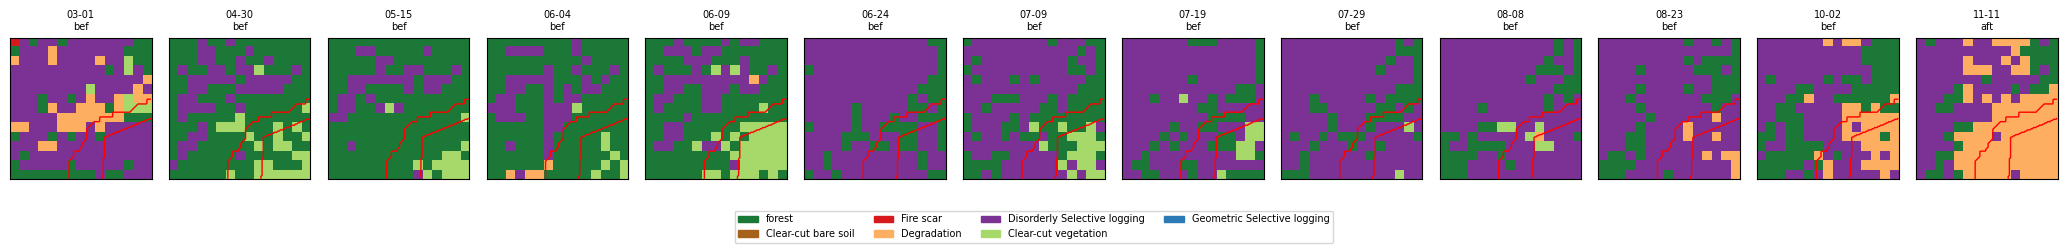

In [3]:
from eval_plots import CMAP, NORM, NAMES, CLASS_COLORS, _outline_polygon
  
TILE = raw.loc[raw.n_tok.idxmax(), "tile"]        # tile with most polygon tokens

with rasterio.open(glob.glob(f"{TILES}/s2_l2a/fid_{FID}/*/*/{TILE}.tif")[0]) as src:
    fine = rasterize(polys, (src.height, src.width), transform=src.transform)

maps = []
for npy in glob.glob(f"embeddings/joint/fid_{FID}/*/*/{TILE}.npy"):
    pred = clf.predict(np.load(npy).reshape(-1, 768)).reshape(15, 15)
    maps.append((re.search(r"(\d{8})T", npy).group(1), npy.split("/")[3], pred))
maps.sort()

n = len(maps)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
for ax, (date, win, pred) in zip(np.atleast_1d(axes), maps):
    ax.imshow(pred, cmap=CMAP, norm=NORM, interpolation="nearest")
    _outline_polygon(ax, fine, 15, 15)            # red = polygon boundary
    ax.set_title(f"{date[4:6]}-{date[6:]}\n{win}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

fig.legend([plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in range(7)],
            NAMES, loc="lower center", ncol=4, fontsize=7)
fig.tight_layout(rect=[0, 0.22, 1, 1])
plt.show()


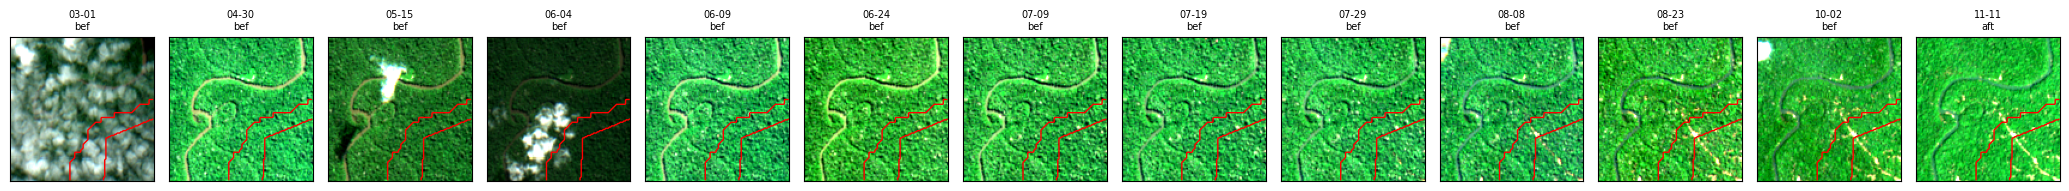

In [4]:
dates_kept = {d for d, _, _ in maps}               # same dates as the class-map figure
  
rgbs = []
for tif in glob.glob(f"{TILES}/s2_l2a/fid_{FID}/*/*/{TILE}.tif"):
    date = re.search(r"(\d{8})T", tif).group(1)
    if date not in dates_kept:
        continue                                   # keep the two figures aligned
    with rasterio.open(tif) as src:
        rgb = np.stack([src.read(b).astype("float32") for b in (4, 3, 2)], -1)
    lo, hi = np.percentile(rgb, [2, 98])           # percentile stretch to [0, 1]
    rgbs.append((date, tif.split("/")[-3], np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)))
rgbs.sort()

n = len(rgbs)
fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
for ax, (date, win, rgb) in zip(np.atleast_1d(axes), rgbs):
    ax.imshow(rgb)
    _outline_polygon(ax, fine, *rgb.shape[:2])     # red = polygon boundary
    ax.set_title(f"{date[4:6]}-{date[6:]}\n{win}", fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

fig.tight_layout()
plt.show()

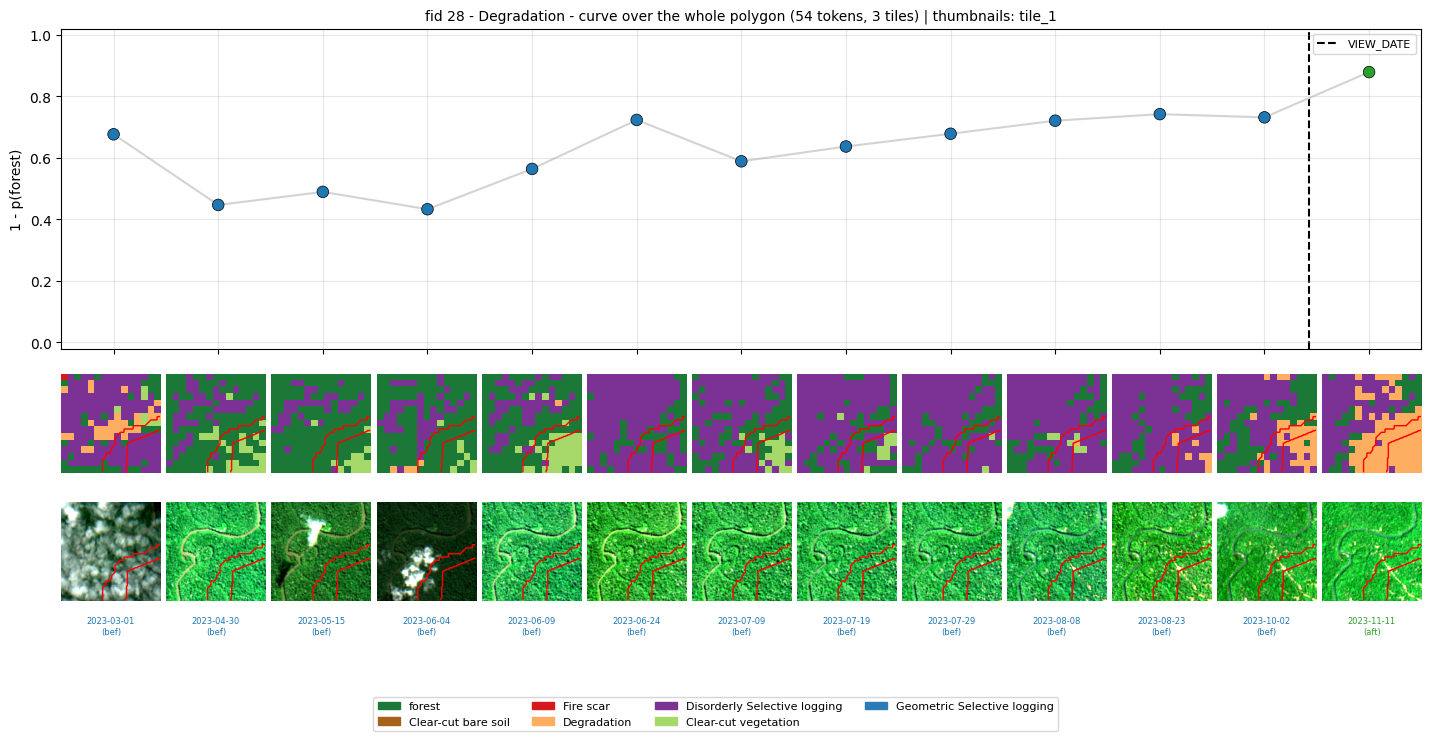

In [5]:
import matplotlib.gridspec as gridspec
from eval_plots import CMAP, NORM, NAMES, CLASS_COLORS, _outline_polygon

WIN_COLORS = {"bef": "tab:blue", "evt": "tab:red", "aft": "tab:green"}

TILE = raw.loc[raw.n_tok.idxmax(), "tile"]        # tile shown in the thumbnails

# Polygon mask for that tile: fine (120x120) for the red outlines.
with rasterio.open(glob.glob(f"{TILES}/s2_l2a/fid_{FID}/*/*/{TILE}.tif")[0]) as src:
    fine = rasterize(polys, (src.height, src.width), transform=src.transform)

# --- Thumbnails: class map + RGB, for the chosen tile only ----------------
thumbs = {}
for npy in glob.glob(f"embeddings/joint/fid_{FID}/*/*/{TILE}.npy"):
    win, img_dir = npy.split("/")[3], npy.split("/")[4]
    s2_id = img_dir.split("__")[0]                 # joint dirs are "<s2id>__<s1id>"

    pred = clf.predict(np.load(npy).reshape(-1, 768)).reshape(15, 15)

    with rasterio.open(f"{TILES}/s2_l2a/fid_{FID}/{win}/{s2_id}/{TILE}.tif") as src:
        rgb = np.stack([src.read(b).astype("float32") for b in (4, 3, 2)], -1)
    lo, hi = np.percentile(rgb, [2, 98])           # percentile stretch to [0, 1]

    thumbs[re.search(r"(\d{8})T", img_dir).group(1)] = {
        "pred": pred, "rgb": np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)}

# --- The curve comes from df: WHOLE polygon, every tile -------------------
curve = df.sort_values("date").reset_index(drop=True)
keys = curve.date.dt.strftime("%Y%m%d")
T = len(curve)
colors = [WIN_COLORS[w] for w in curve.win]
missing = [k for k in keys if k not in thumbs]
if missing:
    print(f"{len(missing)}/{T} dates have no {TILE} thumbnail (other tiles only): {missing}")

fig = plt.figure(figsize=(max(10, 1.35 * T), 8))
gs = gridspec.GridSpec(3, T, height_ratios=[3, 1, 1], hspace=0.12, wspace=0.06)

# Top: FID-level curve. Plotted against index position (not real dates) so
# every point sits exactly above its thumbnails.
ax = fig.add_subplot(gs[0, :])
ax.plot(range(T), curve.p_dist, "-", color="lightgray", zorder=1)
ax.scatter(range(T), curve.p_dist, c=colors, s=70, edgecolors="black", lw=0.5, zorder=3)

# VIEW_DATE interpolated to index position (same trick as joint_pca_with_thumbs)
evt = pd.to_datetime(sub["VIEW_DATE"].iloc[0])
pos = float(np.interp(evt.value, [t.value for t in curve.date], range(T)))
ax.axvline(pos, color="black", ls="--", lw=1.5, zorder=0, label="VIEW_DATE")

ax.set_xlim(-0.5, T - 0.5); ax.set_xticks(range(T)); ax.set_xticklabels([])
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("1 - p(forest)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title(f"fid {FID} - {sub['CLASSNAME'].iloc[0]} - curve over the whole polygon "
            f"({curve.n_tok.iloc[0]} tokens, {curve.n_tiles.iloc[0]} tiles) | "
            f"thumbnails: {TILE}", fontsize=10)

# Middle: predicted class map. Bottom: RGB, date as title.
for i, (key, win) in enumerate(zip(keys, curve.win)):
    t = thumbs.get(key)
    if t is None:
        continue                                   # this tile has no image that date

    ax_map = fig.add_subplot(gs[1, i])
    ax_map.imshow(t["pred"], cmap=CMAP, norm=NORM, interpolation="nearest")
    _outline_polygon(ax_map, fine, 15, 15)         # red polygon boundary
    ax_map.axis("off")

    ax_rgb = fig.add_subplot(gs[2, i])
    ax_rgb.imshow(t["rgb"])
    _outline_polygon(ax_rgb, fine, *t["rgb"].shape[:2])
    ax_rgb.set_title(f"{key[:4]}-{key[4:6]}-{key[6:]}\n({win})",
                    fontsize=6, color=WIN_COLORS[win], y=-0.42)
    ax_rgb.axis("off")

fig.legend([plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in range(7)],
            NAMES, loc="lower center", ncol=4, fontsize=8)
fig.subplots_adjust(bottom=0.16)
plt.show()

fid 28: 4 tiles in a 3x2 grid


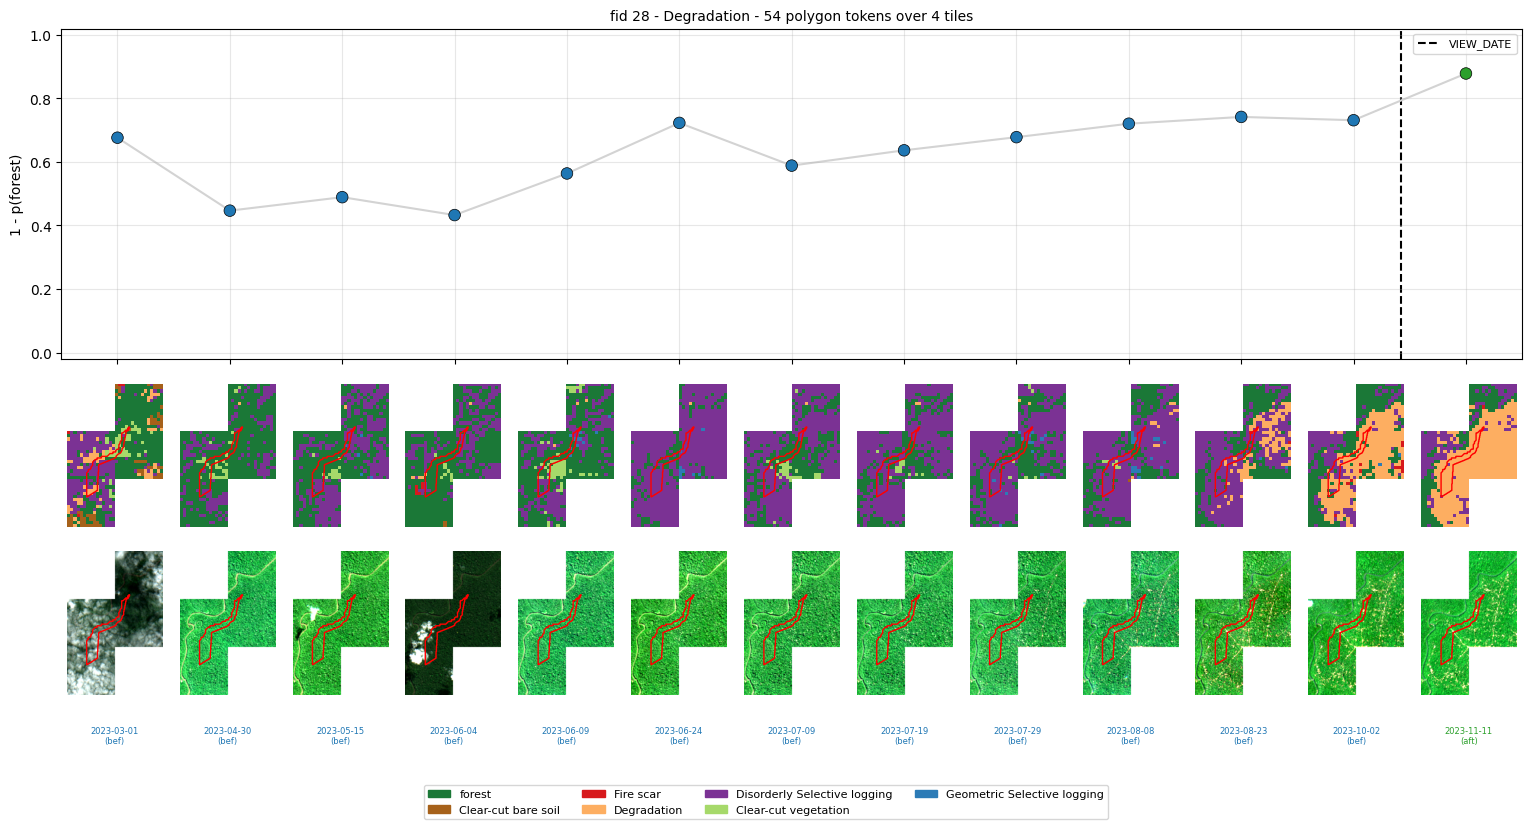

In [7]:
import matplotlib.gridspec as gridspec
from rasterio.transform import from_origin
from eval_plots import CMAP, NORM, NAMES, CLASS_COLORS, _outline_polygon

WIN_COLORS = {"bef": "tab:blue", "evt": "tab:red", "aft": "tab:green"}
TILE_M = 1200.0                                    # 120 px x 10 m per tile

# --- Layout of this FID's tile grid ---------------------------------------
bounds = {}
for tif in glob.glob(f"{TILES}/s2_l2a/fid_{FID}/*/*/tile_*.tif"):
    t = tif.split("/")[-1].replace(".tif", "")
    if t not in bounds:
        with rasterio.open(tif) as src:
            bounds[t] = src.bounds

minx = min(b.left for b in bounds.values())
maxy = max(b.top for b in bounds.values())
# Row/col of each tile in the mosaic, from its geographic corner.
pos = {t: (int(round((maxy - b.top) / TILE_M)), int(round((b.left - minx) / TILE_M)))
        for t, b in bounds.items()}
nrow = max(r for r, _ in pos.values()) + 1
ncol = max(c for _, c in pos.values()) + 1
print(f"fid {FID}: {len(pos)} tiles in a {nrow}x{ncol} grid")

# Polygon rasterized over the FULL mosaic extent, for the red outlines.
fine = rasterize(polys, (nrow * 120, ncol * 120),
                transform=from_origin(minx, maxy, 10, 10))

# --- Assemble one mosaic per acquisition ----------------------------------
frames = {}
for npy in glob.glob(f"embeddings/joint/fid_{FID}/*/*/tile_*.npy"):
    tile = npy.split("/")[-1].replace(".npy", "")
    win, img_dir = npy.split("/")[3], npy.split("/")[4]
    s2_id = img_dir.split("__")[0]                 # joint dirs are "<s2id>__<s1id>"
    date = re.search(r"(\d{8})T", img_dir).group(1)
    if tile not in pos:
        continue

    f = frames.setdefault(date, {
        "win": win,
        "pred": np.full((nrow * 15, ncol * 15), np.nan),      # NaN = no image here
        "rgb": np.full((nrow * 120, ncol * 120, 3), np.nan),
    })
    r, c = pos[tile]

    f["pred"][r * 15:(r + 1) * 15, c * 15:(c + 1) * 15] = clf.predict(np.load(npy).reshape(-1, 768)).reshape(15, 15)

    with rasterio.open(f"{TILES}/s2_l2a/fid_{FID}/{win}/{s2_id}/{tile}.tif") as src:
        f["rgb"][r * 120:(r + 1) * 120, c * 120:(c + 1) * 120] = \
            np.stack([src.read(b).astype("float32") for b in (4, 3, 2)], -1)

# Stretch each date over the WHOLE mosaic, so tiles don't end up mismatched.
for f in frames.values():
    lo, hi = np.nanpercentile(f["rgb"], [2, 98])
    f["rgb"] = np.clip((f["rgb"] - lo) / (hi - lo + 1e-6), 0, 1)

# --- Figure ---------------------------------------------------------------
curve = df.sort_values("date").reset_index(drop=True)
keys = curve.date.dt.strftime("%Y%m%d")
T = len(curve)
colors = [WIN_COLORS[w] for w in curve.win]

cmap = CMAP.copy()
cmap.set_bad("white")                              # tiles missing on that date

fig = plt.figure(figsize=(max(10, 1.45 * T), 9))
gs = gridspec.GridSpec(3, T, height_ratios=[3, 1.3, 1.3], hspace=0.12, wspace=0.06)

# Top: FID-level curve, against index position so points align with thumbnails.
ax = fig.add_subplot(gs[0, :])
ax.plot(range(T), curve.p_dist, "-", color="lightgray", zorder=1)
ax.scatter(range(T), curve.p_dist, c=colors, s=70, edgecolors="black", lw=0.5, zorder=3)

evt = pd.to_datetime(sub["VIEW_DATE"].iloc[0])
pos_evt = float(np.interp(evt.value, [t.value for t in curve.date], range(T)))
ax.axvline(pos_evt, color="black", ls="--", lw=1.5, zorder=0, label="VIEW_DATE")

ax.set_xlim(-0.5, T - 0.5); ax.set_xticks(range(T)); ax.set_xticklabels([])
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("1 - p(forest)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title(f"fid {FID} - {sub['CLASSNAME'].iloc[0]} - "
            f"{curve.n_tok.iloc[0]} polygon tokens over {len(pos)} tiles", fontsize=10)

# Middle: predicted classes. Bottom: RGB. Both mosaicked over the whole FID.
for i, (key, win) in enumerate(zip(keys, curve.win)):
    f = frames.get(key)
    if f is None:
        continue

    ax_map = fig.add_subplot(gs[1, i])
    ax_map.imshow(np.ma.masked_invalid(f["pred"]), cmap=cmap, norm=NORM,
                interpolation="nearest")
    _outline_polygon(ax_map, fine, nrow * 15, ncol * 15)
    ax_map.axis("off")

    ax_rgb = fig.add_subplot(gs[2, i])
    ax_rgb.imshow(np.nan_to_num(f["rgb"], nan=1.0))          # gaps -> white
    _outline_polygon(ax_rgb, fine, nrow * 120, ncol * 120)
    ax_rgb.set_title(f"{key[:4]}-{key[4:6]}-{key[6:]}\n({win})",
                    fontsize=6, color=WIN_COLORS[win], y=-0.40)
    ax_rgb.axis("off")

fig.legend([plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[c]) for c in range(7)],
            NAMES, loc="lower center", ncol=4, fontsize=8)
fig.subplots_adjust(bottom=0.14)
plt.show()